In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

Prvih 5 redova sirovih cena:
                  WTI       BRENT     NVDA
Date                                      
2013-01-01  93.190002  111.400002  0.31925
2013-01-08  94.139999  111.879997  0.30500
2013-01-15  95.559998  110.610001  0.30425
2013-01-22  96.440002  113.480003  0.31525
2013-01-29  96.169998  115.599998  0.30400

Dimenzije: (522, 3)

Prvih 5 redova log-cena:
             log_WTI  log_BRENT  log_NVDA
Date                                     
2013-01-01  4.534640   4.713127 -1.141781
2013-01-08  4.544783   4.717427 -1.187443
2013-01-15  4.559754   4.706011 -1.189906

Prvih 5 redova log-razlika (prinosa):
            Δlog_WTI  Δlog_BRENT  Δlog_NVDA
Date                                       
2013-01-08  0.010143    0.004300  -0.045663
2013-01-15  0.014971   -0.011416  -0.002462
2013-01-22  0.009167    0.025616   0.035516


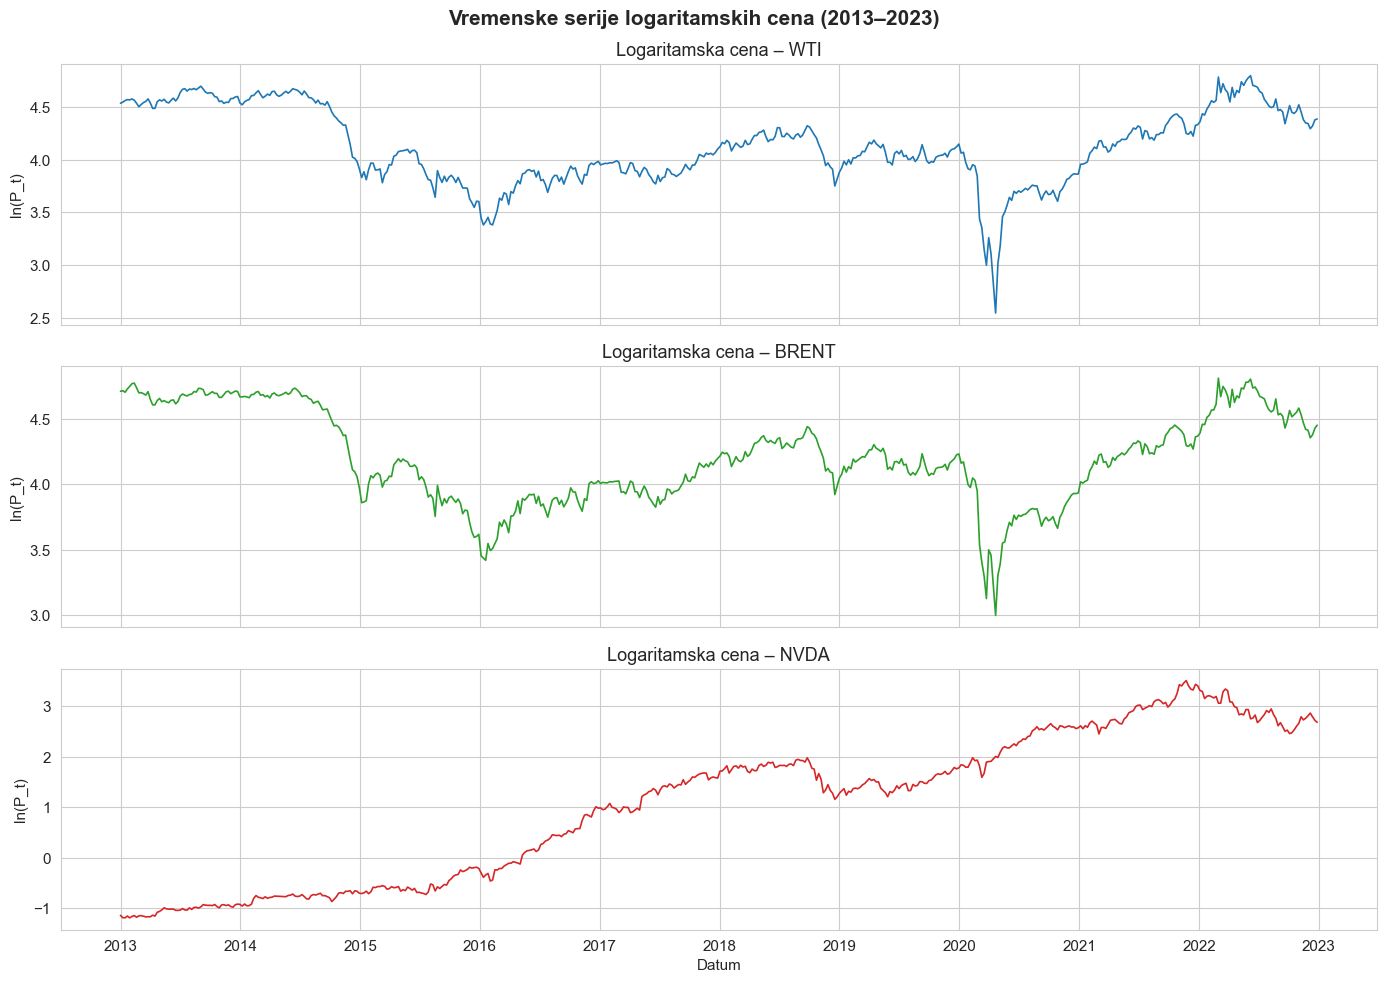

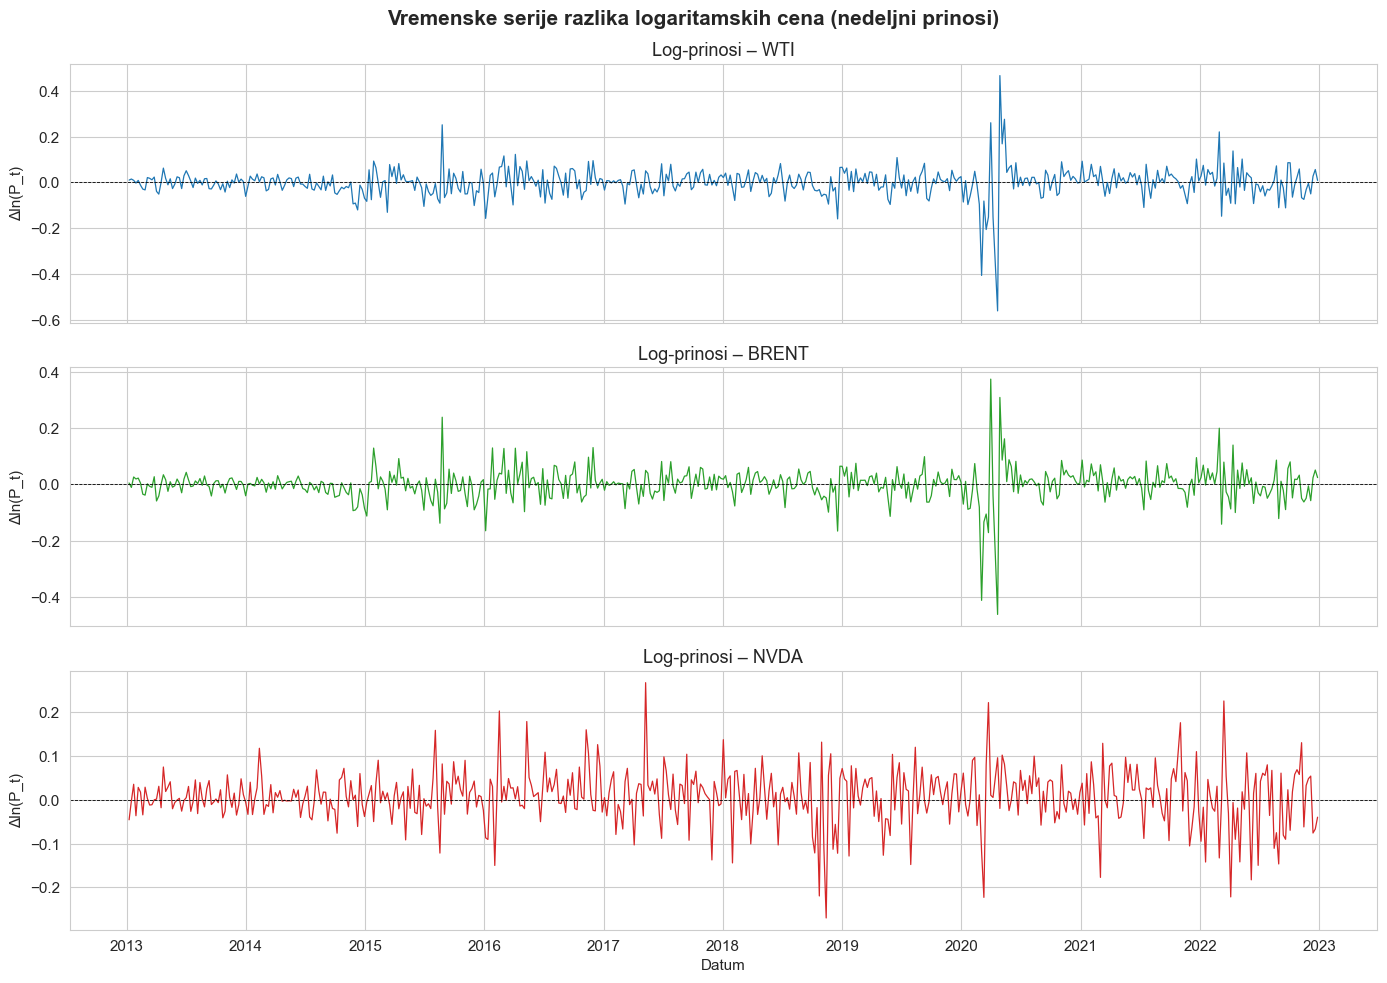

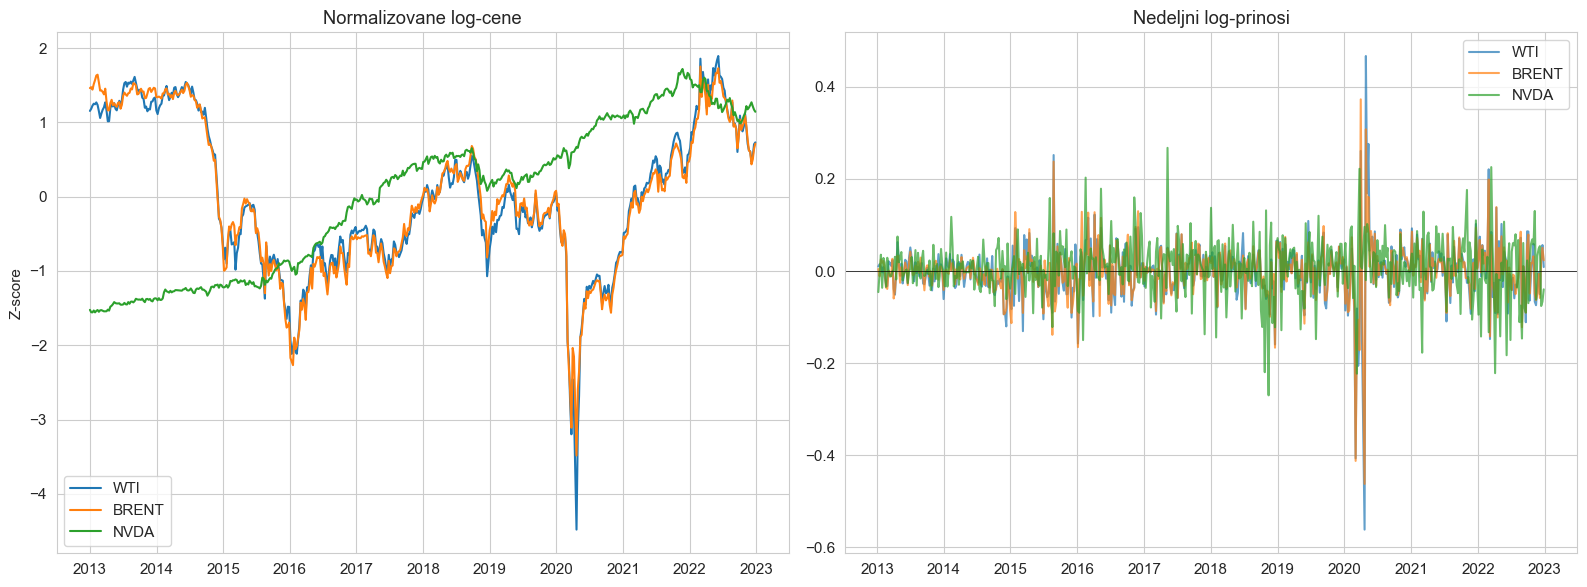

In [3]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

start_date = "2013-01-01"
end_date   = "2023-01-01"

tikeri = {
    "WTI":   "CL=F",
    "BRENT": "BZ=F",
    "NVDA":  "NVDA"
}

podaci = {}
for naziv, tiker in tikeri.items():
    df = yf.download(tiker, start=start_date, end=end_date, interval="1wk",
                     progress=False, auto_adjust=False)
    podaci[naziv] = df['Close'].copy()

cene = pd.concat(podaci, axis=1)
cene.columns = tikeri.keys()
cene = cene.dropna()

print("Prvih 5 redova sirovih cena:")
print(cene.head())
print("\nDimenzije:", cene.shape)
cene = cene[cene > 0].dropna()

log_cene = np.log(cene)
log_cene.columns = [f"log_{c}" for c in log_cene.columns]

log_razlike = log_cene.diff().dropna()
log_razlike.columns = [f"Δ{col}" for col in log_razlike.columns]

print("\nPrvih 5 redova log-cena:")
print(log_cene.head(3))
print("\nPrvih 5 redova log-razlika (prinosa):")
print(log_razlike.head(3))

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

boje = {"log_WTI": "tab:blue", "log_BRENT": "tab:green", "log_NVDA": "tab:red"}

for ax, col in zip(axes, log_cene.columns):
    ax.plot(log_cene.index, log_cene[col], color=boje[col], linewidth=1.2)
    ax.set_title(f"Logaritamska cena – {col.replace('log_','')}", fontsize=13)
    ax.set_ylabel("ln(P_t)")

axes[-1].set_xlabel("Datum")
fig.suptitle("Vremenske serije logaritamskih cena (2013–2023)", fontsize=15, fontweight='bold')
plt.tight_layout()
# plt.savefig("log_cene.png", dpi=150)
plt.show()

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for ax, col in zip(axes, log_razlike.columns):
    ax.plot(log_razlike.index, log_razlike[col],
            color=boje[col.replace('Δ','')], linewidth=0.9)
    ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
    ax.set_title(f"Log-prinosi – {col.replace('Δlog_','').replace('log_','')}", fontsize=13)
    ax.set_ylabel("Δln(P_t)")

axes[-1].set_xlabel("Datum")
fig.suptitle("Vremenske serije razlika logaritamskih cena (nedeljni prinosi)",
             fontsize=15, fontweight='bold')
plt.tight_layout()
# plt.savefig("log_razlike.png", dpi=150)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

norm_log = (log_cene - log_cene.mean()) / log_cene.std()
for col in norm_log.columns:
    axes[0].plot(norm_log.index, norm_log[col], label=col.replace('log_',''))
axes[0].set_title("Normalizovane log-cene")
axes[0].set_ylabel("Z-score")
axes[0].legend()

for col in log_razlike.columns:
    axes[1].plot(log_razlike.index, log_razlike[col], alpha=0.7,
                 label=col.replace('Δlog_','').replace('log_',''))
axes[1].set_title("Nedeljni log-prinosi")
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].legend()

plt.tight_layout()
plt.show()

In [4]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.graphics.tsaplots import plot_acf

def evaluate_white_noise(series, lags=20, alpha=0.05):
    print("=" * 60)
    print("        WEAK WHITE NOISE DIAGNOSTIC REPORT          ")
    print("=" * 60)

    lb_result = acorr_ljungbox(series, lags=[lags], return_df=True)
    lb_pvalue = lb_result['lb_pvalue'].iloc[0]
    bp_pvalue = lb_result['bp_pvalue'].iloc[0] if 'bp_pvalue' in lb_result else None

    print("\n1. AUTOCORRELATION TESTS (Linear Independence)")
    print(f"   • Ljung-Box Test (Lag {lags}): p-value = {lb_pvalue:.4f}")
    if bp_pvalue is not None:
        print(f"   • Box-Pierce Test (Lag {lags}): p-value = {bp_pvalue:.4f}")

    if lb_pvalue > alpha:
        print("   --> RESULT: PASS (No significant autocorrelation detected)")
    else:
        print("   --> RESULT: FAIL (Significant autocorrelation present)")

    adf_result = adfuller(series)
    adf_pvalue = adf_result[1]

    print("\n2. STATIONARITY & CONSTANT MEAN TEST (ADF Test)")
    print(f"   • ADF Statistic: {adf_result[0]:.4f}")
    print(f"   • p-value: {adf_pvalue:.4f}")

    if adf_pvalue < alpha:
        print("   --> RESULT: PASS (Series is stationary around a constant mean)")
    else:
        print("   --> RESULT: FAIL (Unit root detected; mean or trend is shifting)")

    demeaned_series = series - series.mean()
    arch_result = het_arch(demeaned_series, maxlag=lags)
    arch_pvalue = arch_result[1]  # p-value of LM test

    print("\n3. HOMOSCEDASTICITY / CONSTANT VARIANCE (Engle's ARCH Test)")
    print(f"   • ARCH LM p-value: {arch_pvalue:.4f}")

    if arch_pvalue > alpha:
        print("   --> RESULT: PASS (Constant variance / No volatility clustering)")
    else:
        print("   --> RESULT: FAIL (Conditional heteroscedasticity / Volatility clustering present)")

    print("\n" + "-" * 60)
    if lb_pvalue > alpha and adf_pvalue < alpha and arch_pvalue > alpha:
        print("FINAL VERDICT: The series BEHAVES LIKE WEAK WHITE NOISE.")
    elif lb_pvalue > alpha and adf_pvalue < alpha:
        print("FINAL VERDICT: WEAK WHITE NOISE for linear terms, BUT shows non-linear variance dependence (ARCH effects).")
    else:
        print("FINAL VERDICT: The series DOES NOT behave like Weak White Noise.")
    print("-" * 60)

    fig, axes = plt.subplots(3, 1, figsize=(12, 10))
    fig.tight_layout(pad=4.0)

    rolling_window = max(10, len(series) // 20)
    roll_mean = series.rolling(rolling_window).mean()
    roll_std = series.rolling(rolling_window).std()

    axes[0].plot(series.values, label="Data", color="gray", alpha=0.6)
    axes[0].plot(roll_mean.values, label=f"Rolling Mean (win={rolling_window})", color="red", linewidth=1.5)
    axes[0].plot(roll_std.values, label=f"Rolling Std Dev (win={rolling_window})", color="blue", linewidth=1.5)
    axes[0].set_title("Time Series & Rolling Moments")
    axes[0].legend()
    axes[0].grid(True, linestyle=":", alpha=0.6)

    plot_acf(series, lags=lags, ax=axes[1], alpha=alpha)
    axes[1].set_title(f"Autocorrelation Function (ACF) with {int((1-alpha)*100)}% Confidence Bounds")
    axes[1].grid(True, linestyle=":", alpha=0.6)

    axes[2].plot(demeaned_series.values**2, color="purple", alpha=0.7)
    axes[2].set_title("Squared Deviations $(X_t - \\mu)^2$ (Variance Stability Check)")
    axes[2].grid(True, linestyle=":", alpha=0.6)

    plt.show()


 TESTIRANJE BELE BUKE ZA: Δlog_WTI
        WEAK WHITE NOISE DIAGNOSTIC REPORT          

1. AUTOCORRELATION TESTS (Linear Independence)
   • Ljung-Box Test (Lag 15): p-value = 0.1701
   --> RESULT: PASS (No significant autocorrelation detected)

2. STATIONARITY & CONSTANT MEAN TEST (ADF Test)
   • ADF Statistic: -12.1047
   • p-value: 0.0000
   --> RESULT: PASS (Series is stationary around a constant mean)

3. HOMOSCEDASTICITY / CONSTANT VARIANCE (Engle's ARCH Test)
   • ARCH LM p-value: 0.0000
   --> RESULT: FAIL (Conditional heteroscedasticity / Volatility clustering present)

------------------------------------------------------------
FINAL VERDICT: WEAK WHITE NOISE for linear terms, BUT shows non-linear variance dependence (ARCH effects).
------------------------------------------------------------


C:\Users\kosta\AppData\Local\Temp\ipykernel_26068\1664317080.py:37: FutureWarning: the 'maxlag' keyword is deprecated, use 'nlags' instead.
  arch_result = het_arch(demeaned_series, maxlag=lags)


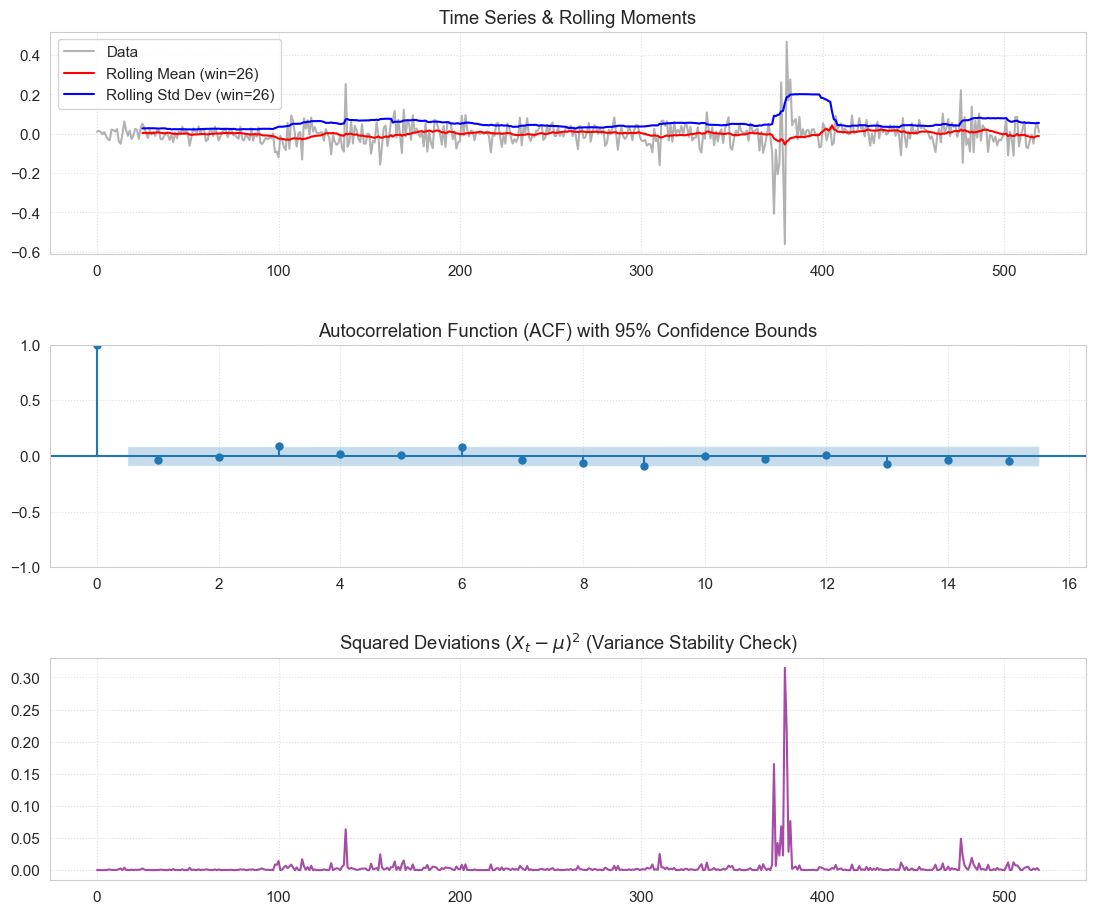


 TESTIRANJE BELE BUKE ZA: Δlog_BRENT
        WEAK WHITE NOISE DIAGNOSTIC REPORT          

1. AUTOCORRELATION TESTS (Linear Independence)
   • Ljung-Box Test (Lag 15): p-value = 0.0909
   --> RESULT: PASS (No significant autocorrelation detected)

2. STATIONARITY & CONSTANT MEAN TEST (ADF Test)
   • ADF Statistic: -12.1938
   • p-value: 0.0000
   --> RESULT: PASS (Series is stationary around a constant mean)

3. HOMOSCEDASTICITY / CONSTANT VARIANCE (Engle's ARCH Test)
   • ARCH LM p-value: 0.0000
   --> RESULT: FAIL (Conditional heteroscedasticity / Volatility clustering present)

------------------------------------------------------------
FINAL VERDICT: WEAK WHITE NOISE for linear terms, BUT shows non-linear variance dependence (ARCH effects).
------------------------------------------------------------


C:\Users\kosta\AppData\Local\Temp\ipykernel_26068\1664317080.py:37: FutureWarning: the 'maxlag' keyword is deprecated, use 'nlags' instead.
  arch_result = het_arch(demeaned_series, maxlag=lags)


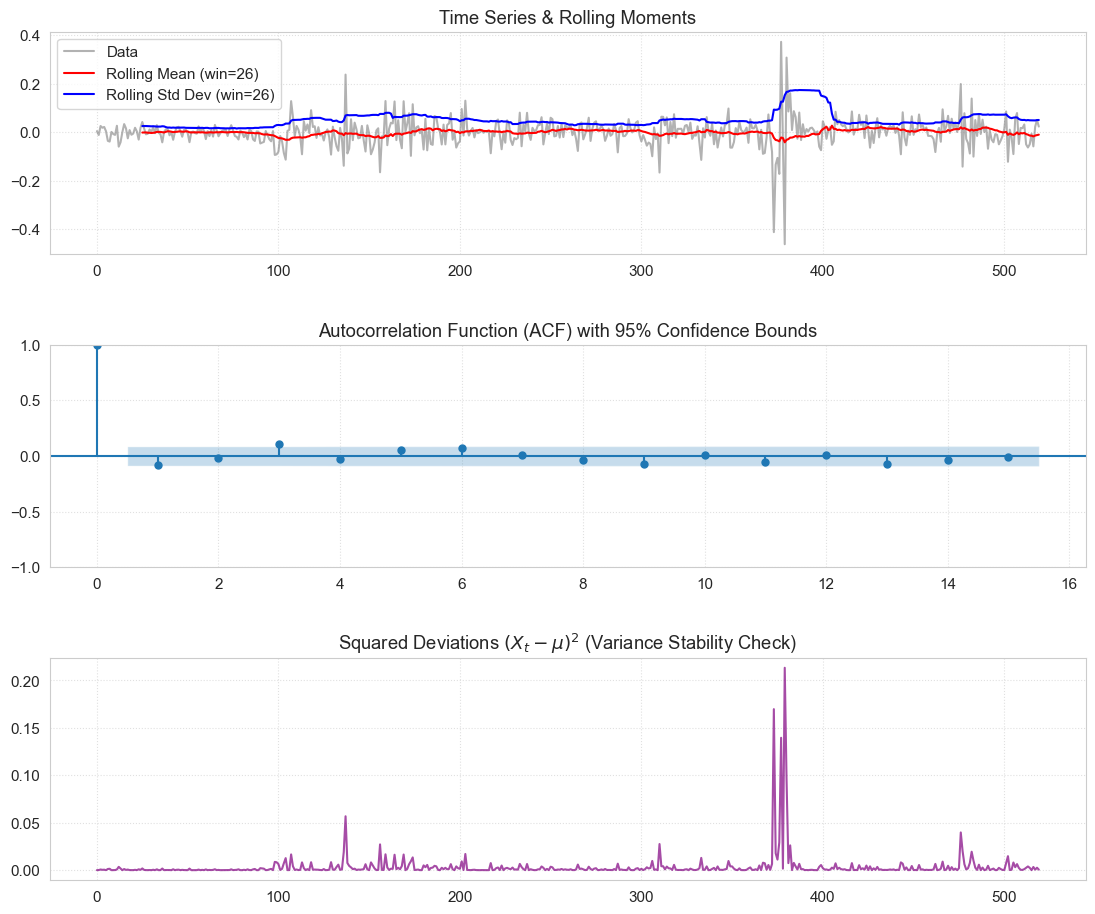


 TESTIRANJE BELE BUKE ZA: Δlog_NVDA
        WEAK WHITE NOISE DIAGNOSTIC REPORT          

1. AUTOCORRELATION TESTS (Linear Independence)
   • Ljung-Box Test (Lag 15): p-value = 0.8489
   --> RESULT: PASS (No significant autocorrelation detected)

2. STATIONARITY & CONSTANT MEAN TEST (ADF Test)
   • ADF Statistic: -17.6010
   • p-value: 0.0000
   --> RESULT: PASS (Series is stationary around a constant mean)

3. HOMOSCEDASTICITY / CONSTANT VARIANCE (Engle's ARCH Test)
   • ARCH LM p-value: 0.0000
   --> RESULT: FAIL (Conditional heteroscedasticity / Volatility clustering present)

------------------------------------------------------------
FINAL VERDICT: WEAK WHITE NOISE for linear terms, BUT shows non-linear variance dependence (ARCH effects).
------------------------------------------------------------


C:\Users\kosta\AppData\Local\Temp\ipykernel_26068\1664317080.py:37: FutureWarning: the 'maxlag' keyword is deprecated, use 'nlags' instead.
  arch_result = het_arch(demeaned_series, maxlag=lags)


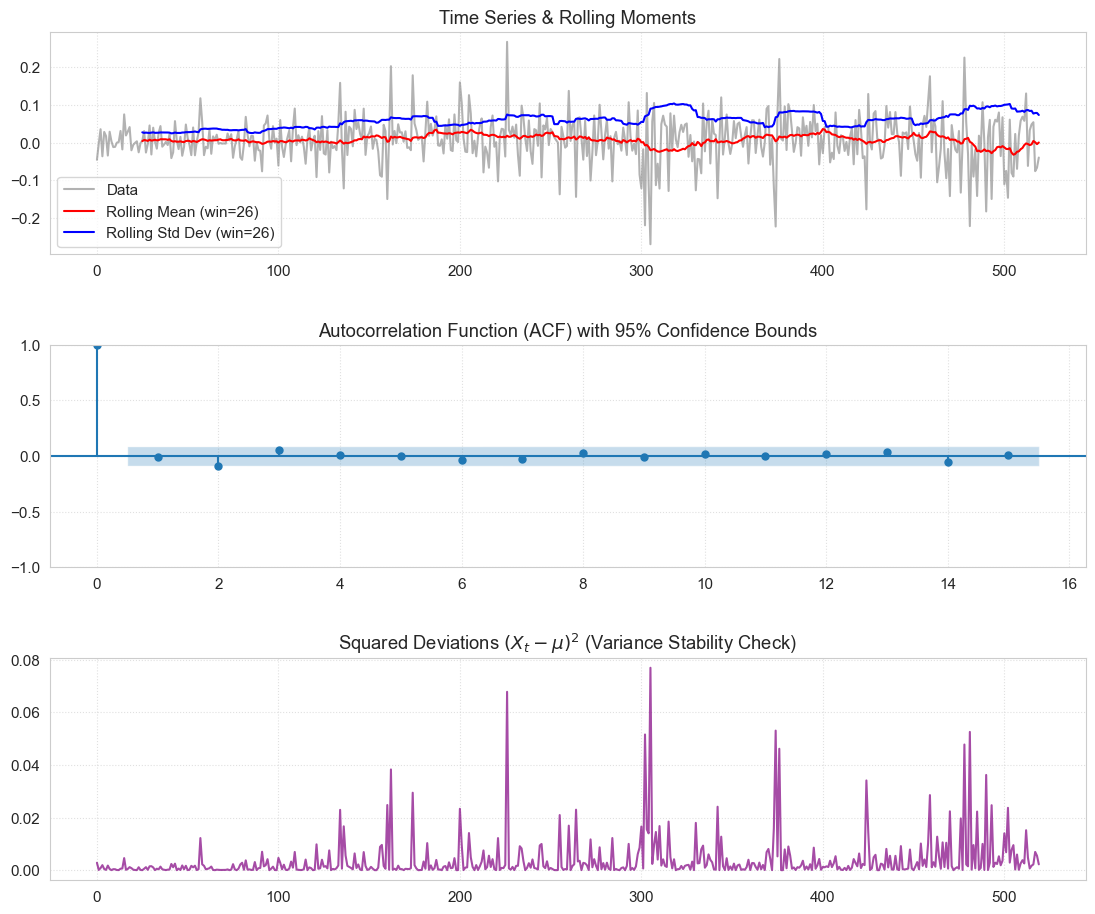

In [5]:
for col in log_razlike.columns:
    print(f"\n=======================================================")
    print(f" TESTIRANJE BELE BUKE ZA: {col}")
    print(f"=======================================================")

    evaluate_white_noise(log_razlike[col], lags=15)


POČETAK AR(1) ANALIZE I TESTA JEDINIČNOG KORENA

--- Analiza za instrument: WTI ---
Ocenjeni parametri:
b = 0.982500
a = 0.071938
Osobine reziduala:
Srednja vrednost e_t: -0.0000000000
Srednja varijansa e_t: 0.004116
ZAKLJUČAK TESTA: Proces je kovarijansno stacioniran.

--- Analiza za instrument: BRENT ---
Ocenjeni parametri:
b = 0.984038
a = 0.066619
Osobine reziduala:
Srednja vrednost e_t: -0.0000000000
Srednja varijansa e_t: 0.003439
ZAKLJUČAK TESTA: Proces je kovarijansno stacioniran.

--- Analiza za instrument: NVDA ---
Ocenjeni parametri:
b = 0.998083
a = 0.009346
Osobine reziduala:
Srednja vrednost e_t: -0.0000000000
Srednja varijansa e_t: 0.003847
ZAKLJUČAK TESTA: Proces je random wlak.



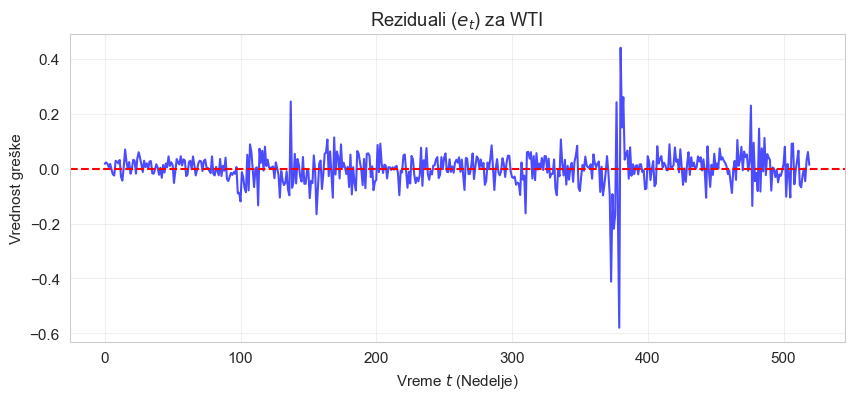

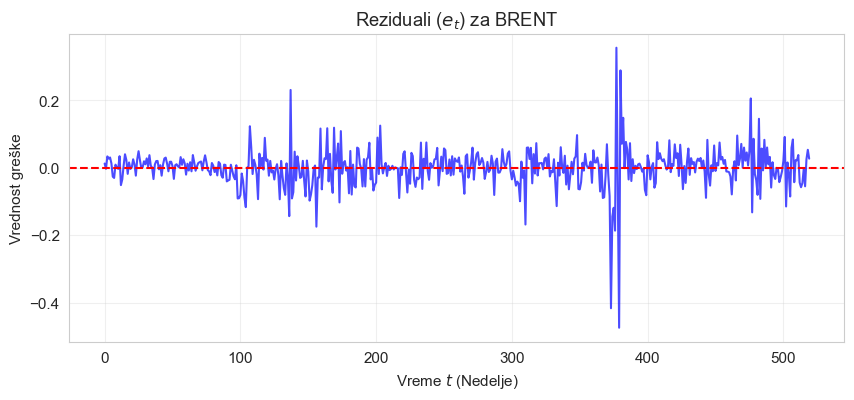

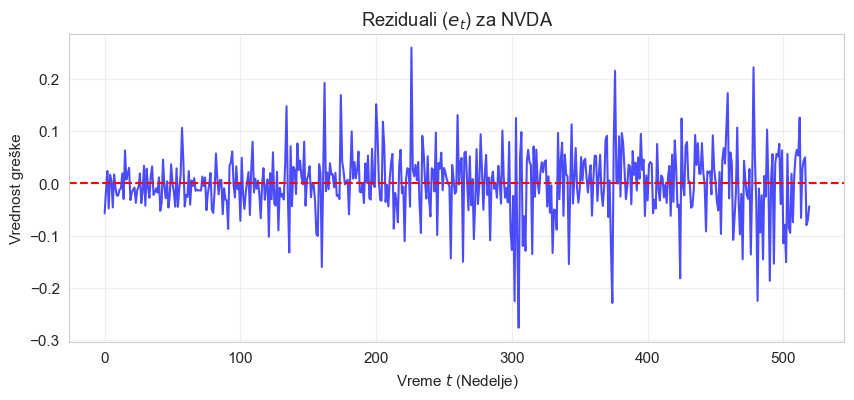

In [6]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime


sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

# start_date = "2013-01-01"
# end_date   = "2023-01-01"

# tikeri = {
#     "WTI":   "CL=F",
#     "BRENT": "BZ=F",
#     "NVDA":  "NVDA"
# }

# podaci = {}
# for naziv, tiker in tikeri.items():
#     df = yf.download(tiker, start=start_date, end=end_date, interval="1wk",
#                      progress=False, auto_adjust=False)
#     podaci[naziv] = df['Close'].copy()

# cene = pd.concat(podaci, axis=1)
# cene.columns = tikeri.keys()
# cene = cene.dropna()

# print("Prvih 5 redova sirovih cena:")
# print(cene.head())
# print("\nDimenzije:", cene.shape)
# cene = cene[cene > 0].dropna()

# log_cene = np.log(cene)
# log_cene.columns = [f"log_{c}" for c in log_cene.columns]

# log_razlike = log_cene.diff().dropna()
# log_razlike.columns = [f"Δ{col}" for col in log_razlike.columns]

# print("\nPrvih 5 redova log-cena:")
# print(log_cene.head(3))
# print("\nPrvih 5 redova log-razlika (prinosa):")
# print(log_razlike.head(3))

# (Tvoji prethodni grafikoni za cene i razlike su ovde izostavljeni radi uštede prostora, 
# ali možeš ih slobodno ostaviti u svom fajlu)

# ==========================================
# IMPLEMENTACIJA AR(1) MODELA I TESTA JEDINIČNOG KORENA
# ==========================================

print("\n" + "="*50)
print("POČETAK AR(1) ANALIZE I TESTA JEDINIČNOG KORENA")
print("="*50 + "\n")

# Funkcija koja izvršava ceo proces na jednom nizu (jednoj koloni iz Pandas DataFrame-a)
def analiziraj_ar1(serija_cena, naziv_instrumenta):
    print(f"--- Analiza za instrument: {naziv_instrumenta} ---")
    
    # Prebacujemo Pandas Series u NumPy array za brži rad i lakše indeksiranje
    niz_cena = serija_cena.values
    
    # Korak 1: Priprema podataka (Kreiranje pomaka - Lagging)
    X_t = niz_cena[:-1]      
    X_t_plus_1 = niz_cena[1:] 

    # Korak 2: Ocenjivanje parametara 'a' i 'b' primenom MNK
    mean_X_t = np.mean(X_t)
    mean_X_t_plus_1 = np.mean(X_t_plus_1)

    brojilac = np.sum((X_t - mean_X_t) * (X_t_plus_1 - mean_X_t_plus_1))
    imenilac = np.sum((X_t - mean_X_t)**2)
    b = brojilac / imenilac
    a = mean_X_t_plus_1 - b * mean_X_t

    print(f"Ocenjeni parametri:")
    print(f"b = {b:.6f}")
    print(f"a = {a:.6f}")

    # Korak 3: Izdvajanje i provera reziduala (e_t)
    e_t = X_t_plus_1 - (a + b * X_t)
    mean_e_t = np.mean(e_t)
    var_e_t = np.var(e_t)

    print(f"Osobine reziduala:")
    print(f"Srednja vrednost e_t: {mean_e_t:.10f}")
    print(f"Srednja varijansa e_t: {var_e_t:.6f}")
    
    # Vizuelna provera reziduala
    # AKO INSTALIRAŠ statsmodels, PROMENI SLEDEĆI BLOK DA CRTA I ACF
    plt.figure(figsize=(10, 4))
    plt.plot(e_t, color='blue', alpha=0.7)
    plt.axhline(0, color='red', linestyle='--')
    plt.title(f'Reziduali ($e_t$) za {naziv_instrumenta}')
    plt.xlabel('Vreme $t$ (Nedelje)')
    plt.ylabel('Vrednost greške')
    plt.grid(True, alpha=0.3)
    #plt.show()

    # Korak 4: Interpretacija (Test jediničnog korena)
    tolerancija = 0.01 
    
    if abs(b) > 1 + tolerancija:
         zakljucak = "Proces divergira."
    elif abs(b - 1) <= tolerancija:
         zakljucak = "Proces je random wlak."
    elif abs(b) < 1:
         zakljucak = "Proces je kovarijansno stacioniran."
    else:
         zakljucak = "Granični slučaj koji zahteva dodatna ispitivanja."
         
    print(f"ZAKLJUČAK TESTA: {zakljucak}\n")

# Pokrećemo analizu za svaku od tri log-cene iz tvog DataFrame-a
for kolona in log_cene.columns:
    # Izvlačimo naziv bez 'log_' prefiksa radi lepšeg ispisa
    naziv = kolona.replace("log_", "") 
    analiziraj_ar1(log_cene[kolona], naziv)